# Data Analysis

In [1]:
import pandas as pd
import numpy as ny
from matplotlib import pyplot as plt

In [2]:
df = pd.read_csv(r"D:\DATA Practice\ecommerce_clickstream_transactions.csv")

In [3]:
df

,UserID,SessionID,Timestamp,EventType,ProductID,Amount,Outcome
0,1,1,2024-07-07 18:00:26.959902,page_view,NaN,NaN,NaN
1,1,1,2024-03-05 22:01:00.072000,page_view,NaN,NaN,NaN
2,1,1,2024-03-23 22:08:10.568453,product_view,prod_8199,NaN,NaN
3,1,1,2024-03-12 00:32:05.495638,add_to_cart,prod_4112,NaN,NaN
4,1,1,2024-02-25 22:43:01.318876,add_to_cart,prod_3354,NaN,NaN
...,...,...,...,...,...,...,...
74812,1000,10,2024-05-11 22:48:45.500117,purchase,prod_1238,186.208225,purchase
74813,1000,10,2024-03-29 04:09:32.514318,logout,NaN,NaN,NaN
74814,1000,10,2024-02-09 02:58:56.128697,login,NaN,NaN,NaN
74815,1000,10,2024-04-30 16:19:48.002633,purchase,prod_2515,198.757849,purchase


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74817 entries, 0 to 74816
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   UserID     74817 non-null  int64  
 1   SessionID  74817 non-null  int64  
 2   Timestamp  74817 non-null  object 
 3   EventType  74817 non-null  object 
 4   ProductID  32113 non-null  object 
 5   Amount     10682 non-null  float64
 6   Outcome    10682 non-null  object 
dtypes: float64(1), int64(2), object(4)
memory usage: 4.0+ MB


In [5]:
df.isnull().sum()

UserID           0
SessionID        0
Timestamp        0
EventType        0
ProductID    42704
Amount       64135
Outcome      64135
dtype: int64

# Data Cleaning
## Handle Null values

In [6]:
df['ProductID'] = df['ProductID'].fillna("no_purchase")

In [7]:
df['Amount'] = df['Amount'].fillna(0)
df['Outcome'] = df['Outcome'].fillna("no_purchase")

In [8]:
df

,UserID,SessionID,Timestamp,EventType,ProductID,Amount,Outcome
0,1,1,2024-07-07 18:00:26.959902,page_view,no_purchase,0.000000,no_purchase
1,1,1,2024-03-05 22:01:00.072000,page_view,no_purchase,0.000000,no_purchase
2,1,1,2024-03-23 22:08:10.568453,product_view,prod_8199,0.000000,no_purchase
3,1,1,2024-03-12 00:32:05.495638,add_to_cart,prod_4112,0.000000,no_purchase
4,1,1,2024-02-25 22:43:01.318876,add_to_cart,prod_3354,0.000000,no_purchase
...,...,...,...,...,...,...,...
74812,1000,10,2024-05-11 22:48:45.500117,purchase,prod_1238,186.208225,purchase
74813,1000,10,2024-03-29 04:09:32.514318,logout,no_purchase,0.000000,no_purchase
74814,1000,10,2024-02-09 02:58:56.128697,login,no_purchase,0.000000,no_purchase
74815,1000,10,2024-04-30 16:19:48.002633,purchase,prod_2515,198.757849,purchase


In [9]:
df.isnull().sum()

UserID       0
SessionID    0
Timestamp    0
EventType    0
ProductID    0
Amount       0
Outcome      0
dtype: int64

# Feature Engineering

## Transform the Data suits for Alogo

In [10]:
events = df.pivot_table(index ='UserID',columns='EventType', aggfunc ='size',fill_value =0)

In [11]:
events.head() 

EventType,add_to_cart,click,login,logout,page_view,product_view,purchase
UserID,,,,,,,
1,23,5,11,6,15,14,8
2,18,10,9,9,10,4,13
3,11,10,5,13,9,10,6
4,14,9,13,12,17,9,9
5,13,15,8,13,14,14,7


In [12]:
amounts = df.groupby('UserID')['Amount'].sum()

In [13]:
final_df = events.merge(amounts, on ='UserID')

In [14]:
final_df.head()

,add_to_cart,click,login,logout,page_view,product_view,purchase,Amount
UserID,,,,,,,,
1,23,5,11,6,15,14,8,1996.128780
2,18,10,9,9,10,4,13,2676.553720
3,11,10,5,13,9,10,6,1512.699392
4,14,9,13,12,17,9,9,2322.826358
5,13,15,8,13,14,14,7,2189.316345


In [15]:
final_df.isnull().sum()

add_to_cart     0
click           0
login           0
logout          0
page_view       0
product_view    0
purchase        0
Amount          0
dtype: int64

# Feature Scaling

In [16]:
final_df

,add_to_cart,click,login,logout,page_view,product_view,purchase,Amount
UserID,,,,,,,,
1,23,5,11,6,15,14,8,1996.128780
2,18,10,9,9,10,4,13,2676.553720
3,11,10,5,13,9,10,6,1512.699392
4,14,9,13,12,17,9,9,2322.826358
5,13,15,8,13,14,14,7,2189.316345
...,...,...,...,...,...,...,...,...
996,10,12,8,9,12,12,12,2486.921889
997,7,12,12,11,14,15,7,1845.607984
998,13,10,5,10,11,17,6,1681.417877


In [17]:
from sklearn.preprocessing import StandardScaler

In [18]:
scaler = StandardScaler()

In [19]:
x_scaler = scaler.fit_transform(final_df)

In [21]:
x_scaler

array([[ 3.72819172, -1.83650889,  0.14266382, ...,  1.09697941,
        -0.84944581, -0.77543003],
       [ 2.20834185, -0.20608552, -0.51781684, ..., -2.22317619,
         0.73415935, -0.0306686 ],
       [ 0.08055204, -0.20608552, -1.83877816, ..., -0.23108283,
        -1.48288787, -1.30456931],
       ...,
       [ 0.68849199, -0.20608552, -1.83877816, ...,  2.09302609,
        -1.48288787, -1.11989792],
       [-0.5273879 ,  0.11999916,  0.80314448, ..., -0.56309839,
         0.41743832,  0.01570977],
       [ 0.08055204,  0.44608384,  0.14266382, ...,  1.09697941,
         1.05088038,  0.38517645]], shape=(1000, 8))

# Find Kmeans Value by Elbow Method

In [27]:
from sklearn.cluster import KMeans

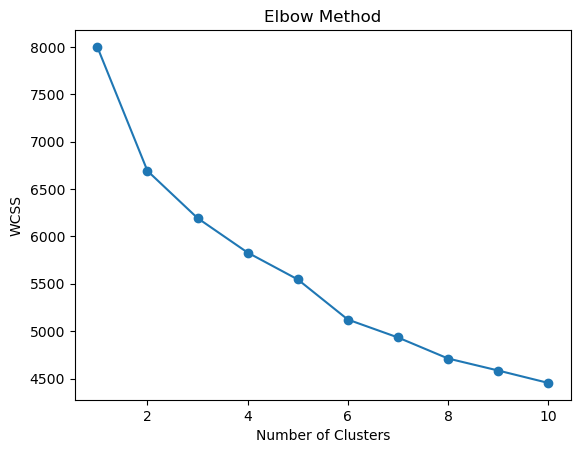

In [28]:
#create an empty list
wcss = [] #within cluster some of squares ( measure how tight the clusters are we will store wcss for diffrent k values
for i in range(1,11): #We test a range of K values to observe how WCSS changes and identify the optimal cluster count
    km = KMeans(n_clusters=i, random_state=42)
    km.fit(x_scaler)
    wcss.append(km.inertia_) #How close the data points are to their cluster center (centroid)
plt.plot(range(1,11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

# Create K-Means clusters

In [29]:
kmeans = KMeans(n_clusters=6, random_state=42)
y_kmeans = kmeans.fit_predict(x_scaler)

In [30]:
y_kmeans

array([4, 0, 1, 2, 1, 5, 2, 3, 5, 5, 4, 2, 3, 1, 5, 4, 3, 1, 5, 4, 4, 2,
       4, 1, 5, 3, 1, 5, 5, 4, 2, 3, 2, 0, 5, 4, 2, 4, 5, 0, 2, 2, 5, 2,
       5, 3, 4, 0, 4, 5, 0, 1, 3, 2, 0, 2, 3, 4, 3, 1, 2, 3, 4, 3, 3, 0,
       2, 4, 1, 5, 2, 4, 1, 0, 4, 1, 2, 4, 1, 1, 4, 3, 4, 0, 3, 3, 0, 5,
       1, 3, 5, 4, 1, 5, 1, 1, 1, 0, 2, 3, 5, 5, 3, 0, 2, 0, 2, 4, 0, 1,
       2, 0, 3, 0, 4, 0, 0, 2, 4, 2, 0, 1, 5, 0, 4, 5, 4, 5, 4, 5, 2, 3,
       1, 4, 0, 5, 5, 1, 4, 3, 2, 0, 1, 4, 1, 4, 2, 5, 2, 5, 1, 4, 2, 3,
       3, 1, 1, 5, 1, 1, 3, 5, 0, 4, 5, 0, 4, 0, 1, 5, 1, 5, 0, 2, 1, 3,
       2, 5, 3, 3, 5, 4, 5, 3, 1, 1, 0, 1, 3, 4, 4, 0, 1, 5, 0, 0, 5, 5,
       2, 4, 4, 1, 2, 3, 3, 3, 5, 4, 0, 5, 5, 3, 3, 5, 5, 5, 2, 1, 5, 5,
       5, 3, 1, 5, 1, 4, 1, 3, 0, 1, 2, 4, 2, 2, 4, 5, 2, 0, 5, 1, 4, 5,
       3, 0, 1, 1, 0, 1, 1, 0, 2, 2, 0, 3, 2, 2, 0, 4, 5, 5, 5, 4, 5, 5,
       5, 3, 1, 4, 5, 5, 5, 4, 1, 0, 0, 2, 5, 1, 4, 1, 1, 1, 4, 1, 1, 5,
       1, 1, 0, 1, 4, 4, 4, 4, 5, 1, 4, 1, 1, 2, 0,

In [31]:
final_df['cluster']=y_kmeans

In [32]:
final_df

,add_to_cart,click,login,logout,page_view,product_view,purchase,Amount,cluster
UserID,,,,,,,,,
1,23,5,11,6,15,14,8,1996.128780,4
2,18,10,9,9,10,4,13,2676.553720,0
3,11,10,5,13,9,10,6,1512.699392,1
4,14,9,13,12,17,9,9,2322.826358,2
5,13,15,8,13,14,14,7,2189.316345,1
...,...,...,...,...,...,...,...,...,...
996,10,12,8,9,12,12,12,2486.921889,2
997,7,12,12,11,14,15,7,1845.607984,2
998,13,10,5,10,11,17,6,1681.417877,3


# To find high and low activity users

In [33]:
final_df.groupby('cluster').mean()

,add_to_cart,click,login,logout,page_view,product_view,purchase,Amount
cluster,,,,,,,,
0,12.763889,14.215278,10.604167,9.076389,9.881944,9.354167,9.812500,2440.550808
1,10.203593,10.928144,9.383234,14.526946,9.874251,10.161677,8.688623,2077.021629
2,8.757576,11.196970,9.939394,9.598485,15.469697,10.734848,9.303030,2299.183997
3,12.347826,9.079710,7.934783,9.905797,9.840580,14.036232,11.920290,3149.822975
4,11.583784,8.864865,13.421622,10.264865,10.448649,11.562162,8.427027,2078.888125
5,9.358974,10.209402,11.042735,10.337607,10.316239,9.226496,14.470085,3775.679102
